# Manipulación de imágenes

## Descripción

En esta actividad haremos uso de los filtros y transformaciones vistos en clase y otros más que nos presenten las diferentes bibliotecas de funciones de manipulación de imágenes.

***

## Objetivo

Hacer uso de las herramientas de manipulación de imágenes y comprender el uso de la biblioteca seleccionada de la Tarea anterior. 

***

## Tecnologías usadas

OpenCV
NumPy
Matplotlib

***

## Instalación de librerías


In [1]:
# Instalación de bibliotecas
%pip install opencv-python numpy matplotlib

# Versión de Python y SO
import sys
import platform
import cv2
import numpy as np
import matplotlib

print(f"Sistema Operativo : {platform.system()} {platform.release()} ({platform.version()})")
print(f"Python            : {sys.version}")
print(f"OpenCV            : {cv2.__version__}")
print(f"NumPy             : {np.__version__}")
print(f"Matplotlib        : {matplotlib.__version__}")

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   - -------------------------------------- 1.0/40.2 MB 8.8 MB/s eta 0:00:05
   ---- ----------------------------------- 4.7/40.2 MB 12.0 MB/s eta 0:00:03
   ------- -------------------------------- 7.9/40.2 MB 13.1 MB/s eta 0:00:03
   ----------- ---------------------------- 11.5/40.2 MB 14.4 MB/s eta 0:00:02
   ------------ --------------------------- 12.8/40.2 MB 12.5 MB/s eta 0:00:03
   --------------- ------------------------ 15.5/40.2 MB 12.5 MB/s eta 0:00:02
   ------------------ --------------------- 18.6/40.2 MB 12.8 MB/s eta 0:00:02
   -------------------- ------------------- 20.4/40.2 MB 12.5 MB/s eta 0:00:02
   ---------------------- ----------------- 22.3/40.2 MB 12.0 MB/s eta 0:00:02
   ------------------------ --------------- 24.6/40.2 MB 11.9 MB/s eta 0:00:02
   -------------------------- ------------- 27.0/40.2 MB 11.9 MB/s eta 0:00:02
   ----------------------------- ---------- 29.4/40.2 MB 11.8 MB/

## Operaciones

En este trabajo se presentan diversas técnicas de procesamiento digital de imágenes utilizando la biblioteca OpenCV en Python. El objetivo es aplicar transformaciones básicas como histogramas, rotaciones, filtros y ajustes de contraste para comprender su impacto visual.

**Imagen original:**

![byakko](byakko.jpeg)

Ruta de la imagen:

In [2]:
byakko = 'byakko.jpeg'

### Histograma

Un **histograma de imagen** es una representación gráfica de la distribución de los valores de intensidad de los píxeles de una imagen. El eje horizontal representa los posibles valores de intensidad (0–255 para imágenes de 8 bits), mientras que el eje vertical muestra la frecuencia (cantidad de píxeles) con cada valor. En imágenes a color (BGR/RGB), se puede calcular un histograma por canal (Azul, Verde, Rojo), lo que permite analizar la distribución del color en la imagen. Esta herramienta es fundamental para entender el contraste, brillo y equilibrio de colores de una imagen.

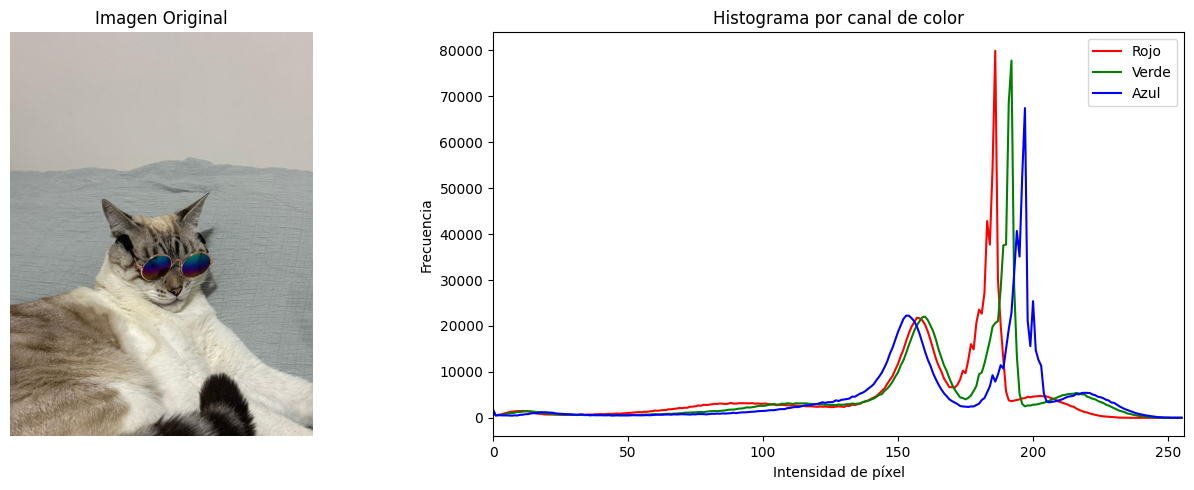

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imagen
img = cv2.imread(byakko)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Imagen original
axes[0].imshow(img_rgb)
axes[0].set_title('Imagen Original')
axes[0].axis('off')

# Histograma por canal de color
colores   = ('r', 'g', 'b')
etiquetas = ('Rojo', 'Verde', 'Azul')
for i, (col, etiqueta) in enumerate(zip(colores, etiquetas)):
    hist = cv2.calcHist([img], [i], None, [256], [0, 256])
    axes[1].plot(hist, color=col, label=etiqueta)
axes[1].set_title('Histograma por canal de color')
axes[1].set_xlabel('Intensidad de píxel')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

### Mirror/Espejo

La operación de **espejo** (o volteo) consiste en reflejar la imagen a lo largo de un eje. Existen dos variantes principales:

- **Espejo horizontal:** Se refleja la imagen a lo largo del eje vertical, de modo que la parte izquierda pasa a ser la derecha y viceversa.
- **Espejo vertical:** Se refleja la imagen a lo largo del eje horizontal, de modo que la parte superior pasa a ser la inferior y viceversa.

En OpenCV esta operación se realiza con la función `cv2.flip()`, donde el parámetro `flipCode` determina el tipo de volteo: `1` para horizontal, `0` para vertical y `-1` para ambos ejes simultáneamente.

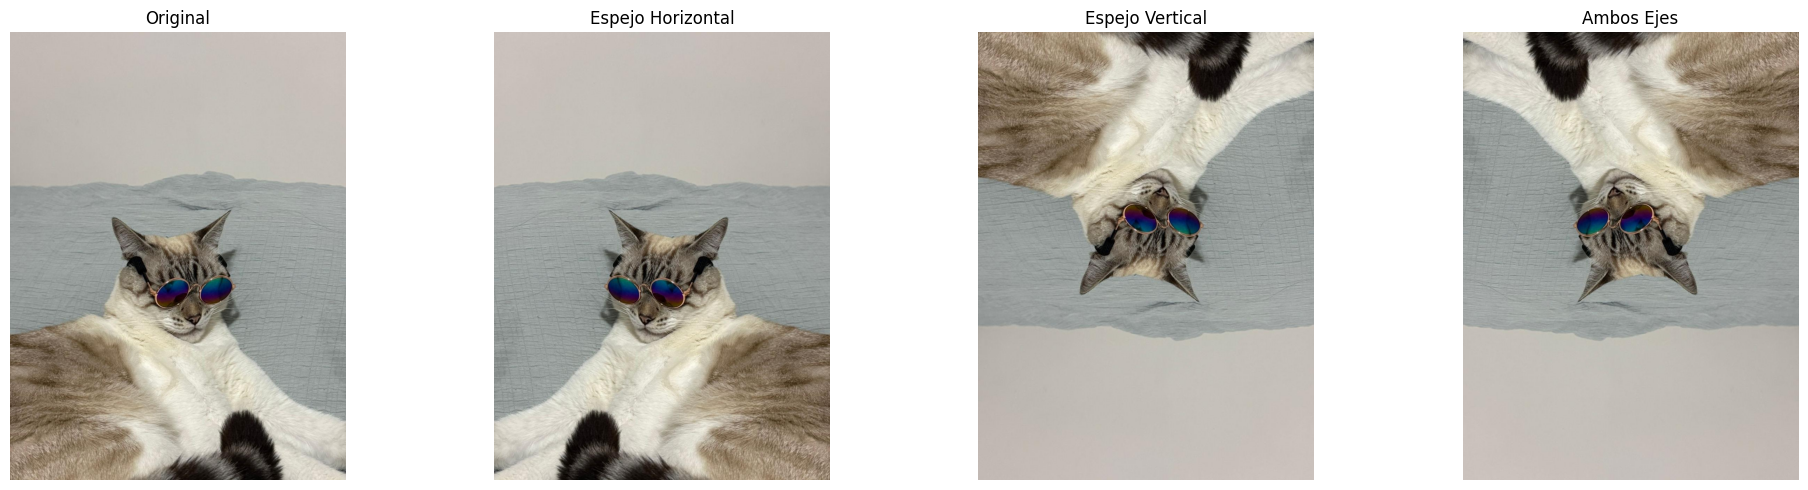

In [4]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(byakko)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

flip_h    = cv2.flip(img_rgb,  1)   # Espejo horizontal
flip_v    = cv2.flip(img_rgb,  0)   # Espejo vertical
flip_both = cv2.flip(img_rgb, -1)   # Ambos ejes

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
images = [img_rgb, flip_h, flip_v, flip_both]
titles = ['Original', 'Espejo Horizontal', 'Espejo Vertical', 'Ambos Ejes']

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Rotación 90, 180, 270

La **rotación** es una transformación geométrica que gira la imagen un número de grados determinado alrededor de un punto (generalmente el centro). Las rotaciones más comunes son múltiplos de 90°:

- **90°:** La imagen se gira un cuarto de vuelta en sentido horario.
- **180°:** La imagen queda invertida, como si se hubiera girado media vuelta.
- **270°:** Equivale a una rotación de 90° en sentido antihorario.

En OpenCV se utiliza `cv2.rotate()` con las constantes `cv2.ROTATE_90_CLOCKWISE`, `cv2.ROTATE_180` y `cv2.ROTATE_90_COUNTERCLOCKWISE` para rotaciones de 90°, 180° y 270° respectivamente, sin recorte ni pérdida de información.

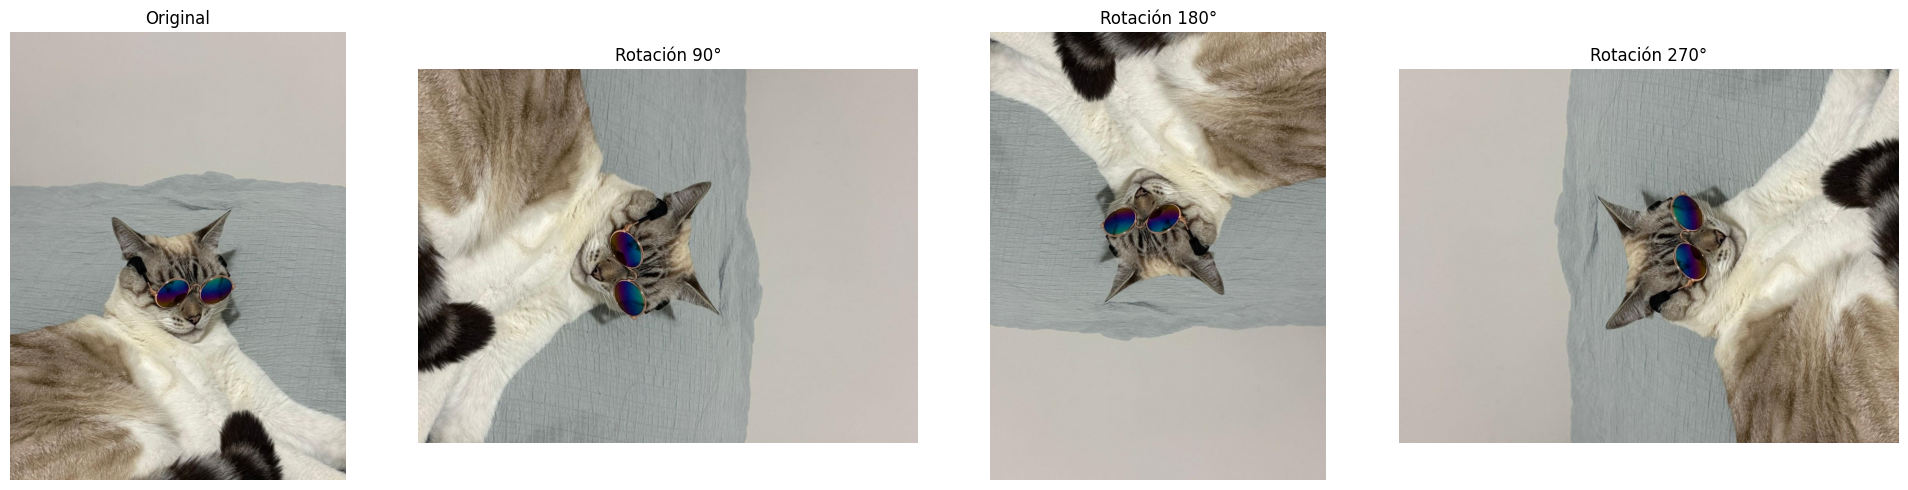

In [5]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(byakko)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

rot_90  = cv2.rotate(img_rgb, cv2.ROTATE_90_CLOCKWISE)
rot_180 = cv2.rotate(img_rgb, cv2.ROTATE_180)
rot_270 = cv2.rotate(img_rgb, cv2.ROTATE_90_COUNTERCLOCKWISE)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
images = [img_rgb, rot_90, rot_180, rot_270]
titles = ['Original', 'Rotación 90°', 'Rotación 180°', 'Rotación 270°']

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Negativo

El **negativo** de una imagen es el resultado de invertir los valores de intensidad de cada píxel. Para imágenes de 8 bits (valores entre 0 y 255), el negativo se calcula como:

> **Negativo(p) = 255 − p**

Donde `p` es el valor original del píxel. Los píxeles oscuros se vuelven claros y viceversa, generando el efecto visual característico de un negativo fotográfico. Esta operación es útil para resaltar detalles en zonas muy oscuras de la imagen o como paso previo en ciertos algoritmos de segmentación y detección de bordes.

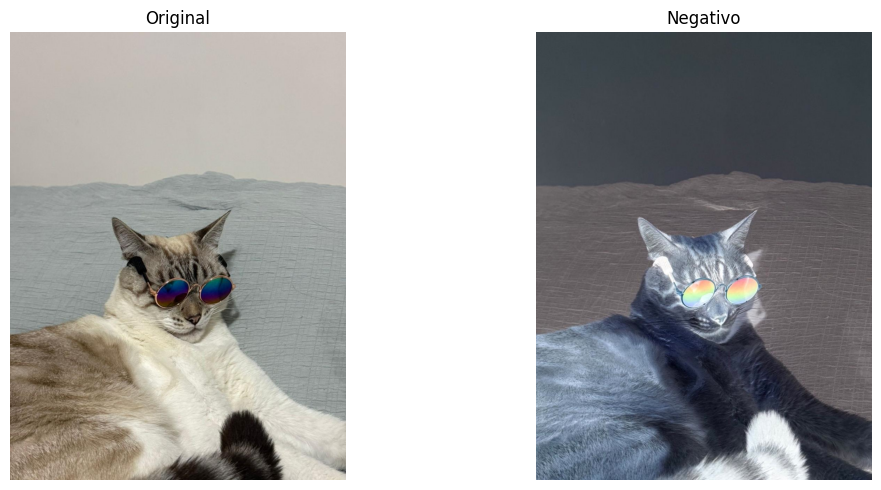

In [6]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(byakko)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Negativo: invertir valores de cada píxel
negativo = 255 - img_rgb

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, image, title in zip(axes, [img_rgb, negativo], ['Original', 'Negativo']):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Contraste

El **contraste** de una imagen hace referencia a la diferencia de luminosidad entre las zonas más claras y las más oscuras. Ajustar el contraste permite resaltar detalles que de otro modo serían difíciles de distinguir.

Una forma común de modificar el contraste es mediante la transformación lineal:

> **g(x, y) = α · f(x, y) + β**

Donde:
- `f(x, y)` es el valor del píxel original.
- `α` (**alpha**) controla el **contraste**: valores > 1 lo aumentan, valores entre 0 y 1 lo reducen.
- `β` (**beta**) controla el **brillo**: valores positivos aclaran la imagen, negativos la oscurecen.

En OpenCV esto se aplica con `cv2.convertScaleAbs()`.

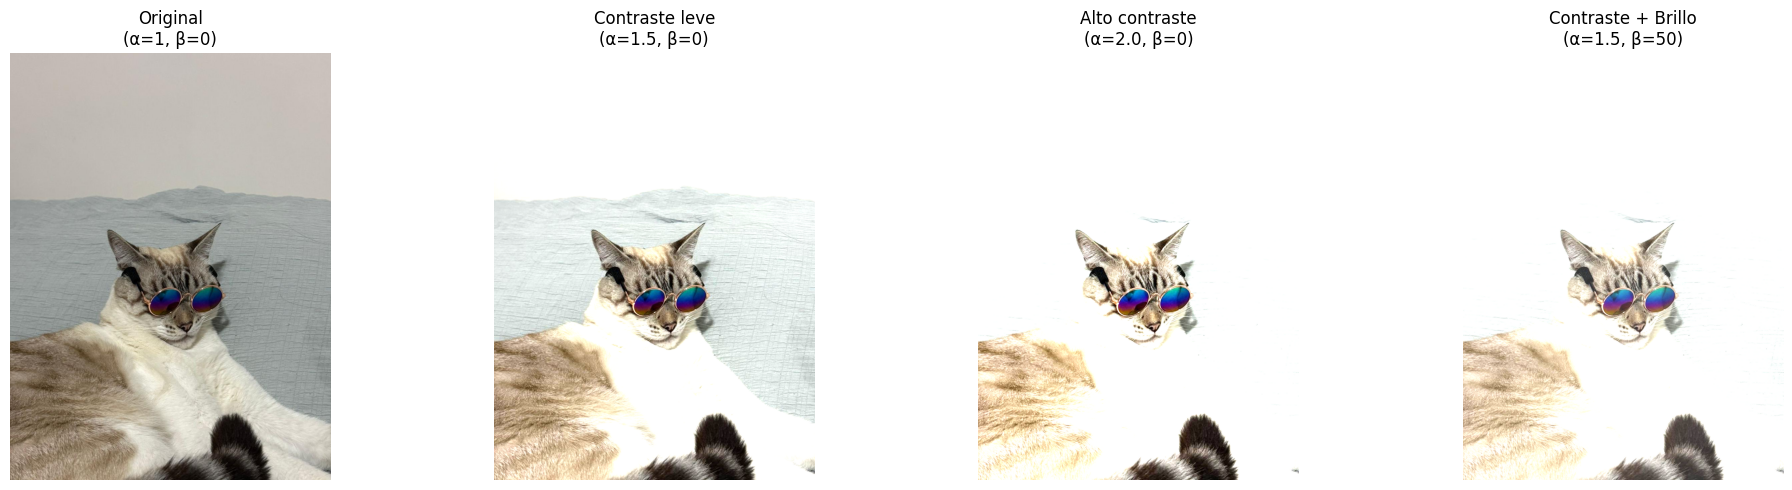

In [7]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(byakko)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Configuraciones (alpha, beta)
configs = [(1.0, 0), (1.5, 0), (2.0, 0), (1.5, 50)]
titles  = ['Original\n(α=1, β=0)', 'Contraste leve\n(α=1.5, β=0)',
           'Alto contraste\n(α=2.0, β=0)', 'Contraste + Brillo\n(α=1.5, β=50)']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (alpha, beta), title in zip(axes, configs, titles):
    ajustada = cv2.convertScaleAbs(img_rgb, alpha=alpha, beta=beta)
    ax.imshow(ajustada)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Operación extra (blur)

El **desenfoque** (blur) es un filtro de suavizado que reduce el ruido y los detalles finos de una imagen promediando los valores de los píxeles en un vecindario definido por un **kernel**. Existen varios tipos en OpenCV:

- **Blur promedio (`cv2.blur`):** Cada píxel se reemplaza por el promedio aritmético de sus vecinos dentro de un kernel rectangular. Es el más simple pero puede producir artefactos en los bordes.
- **Blur Gaussiano (`cv2.GaussianBlur`):** Aplica un promedio ponderado con distribución gaussiana, dando más peso al píxel central. Produce un suavizado más natural y es ampliamente usado como preprocesamiento.
- **Blur de mediana (`cv2.medianBlur`):** Reemplaza cada píxel por la mediana de su vecindario. Es especialmente eficaz para eliminar ruido de tipo "sal y pimienta" preservando los bordes mejor que los anteriores.

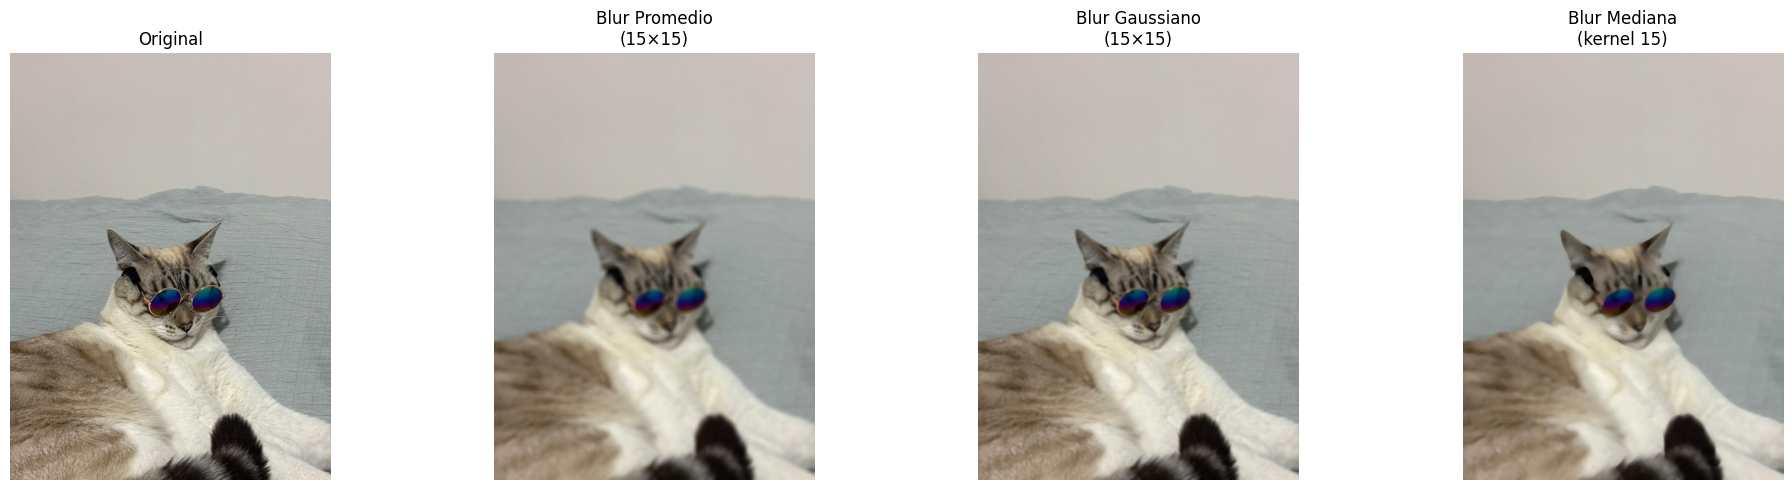

In [8]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(byakko)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

blur_avg    = cv2.blur(img_rgb, (15, 15))
blur_gauss  = cv2.GaussianBlur(img_rgb, (15, 15), 0)
blur_median = cv2.medianBlur(img_rgb, 15)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
images = [img_rgb, blur_avg, blur_gauss, blur_median]
titles = ['Original', 'Blur Promedio\n(15×15)', 'Blur Gaussiano\n(15×15)', 'Blur Mediana\n(kernel 15)']

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

***

## Referencias

1. [OpenCV Documentation – Image Processing](https://docs.opencv.org/4.x/d2/d96/tutorial_py_table_of_contents_imgproc.html)

2. [NumPy Documentation](https://numpy.org/doc/stable/)

3. [Matplotlib Documentation](https://matplotlib.org/stable/index.html)

4. [Repositorio de GitHub con Jupiter Notebook de la Practica.](https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/tree/main/Cuatrimestre%202/4%20-%20Percepci%C3%B3n%20Computacional/Tarea%2002)